In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI_MoodMate1/fer-2013.zip"
extract_path = "/content/fer2013"

# Extract only if not already extracted
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

# Check folders
print(os.listdir(extract_path))


['val', 'test', 'train']


In [3]:
# =========================
# efficient_gray_cnn.py
# =========================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# -----------------------------
# 1️⃣ Basic Configuration
# -----------------------------
img_size = (48, 48)
batch_size = 64
epochs = 80
num_classes = 7  # For FER2013 or similar datasets

# -----------------------------
# 2️⃣ Data Preprocessing
# -----------------------------
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "fer2013/train",
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    "fer2013/train",
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

# -----------------------------
# 3️⃣ Build Efficient CNN Model
# -----------------------------
def conv_block(x, filters, kernel_size=3, stride=1):
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU(6.)(x)
    return x

def depthwise_separable_conv(x, filters):
    x = layers.DepthwiseConv2D(kernel_size=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU(6.)(x)
    x = layers.Conv2D(filters, 1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU(6.)(x)
    return x

def build_efficient_gray_cnn(input_shape=(48, 48, 1), num_classes=7):
    inputs = layers.Input(shape=input_shape)

    x = conv_block(inputs, 32, 3, 2)
    x = depthwise_separable_conv(x, 64)
    x = depthwise_separable_conv(x, 128)
    x = layers.MaxPooling2D(pool_size=(2,2))(x)

    x = depthwise_separable_conv(x, 128)
    x = depthwise_separable_conv(x, 256)
    x = layers.MaxPooling2D(pool_size=(2,2))(x)

    x = depthwise_separable_conv(x, 512)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="EfficientGrayCNN")
    return model

# -----------------------------
# 4️⃣ Compile Model
# -----------------------------
model = build_efficient_gray_cnn(input_shape=(48, 48, 1), num_classes=num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# 5️⃣ Callbacks
# -----------------------------
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ModelCheckpoint("best_efficient_gray_cnn.h5", monitor='val_accuracy', save_best_only=True)
]

# -----------------------------
# 6️⃣ Train the Model
# -----------------------------
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=callbacks
)

# -----------------------------
# 7️⃣ Evaluate & Save
# -----------------------------
train_acc = history.history['accuracy'][-1] * 100
val_acc = history.history['val_accuracy'][-1] * 100
print(f"\n✅ Final Training Accuracy: {train_acc:.2f}%")
print(f"✅ Final Validation Accuracy: {val_acc:.2f}%")

model.save("final_efficient_gray_cnn.h5")
print("\n🎉 Model saved as final_efficient_gray_cnn.h5")


Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.


Model: "EfficientGrayCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 24, 24, 32)     │           288 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 24, 24, 64)     │           576 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_2              │ (None, 12, 12, 128)    │         1,152 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 206,727 (807.53 KB)

 Trainable params: 203,271 (794.03 KB)

...

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.5235 - loss: 1.2488 - val_accuracy: 0.5196 - val_loss: 1.2601
Epoch 71/80
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.5289 - loss: 1.2526 - val_accuracy: 0.5170 - val_loss: 1.2597
Epoch 72/80
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.5251 - loss: 1.2456 - val_accuracy: 0.5192 - val_loss: 1.2682
Epoch 73/80
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.5304 - loss: 1.2376 - val_accuracy: 0.5098 - val_loss: 1.2855
Epoch 74/80
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.5374 - loss: 1.2280 - val_accuracy: 0.5116 - val_loss: 1.2714
Epoch 75/80
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5358 - loss: 1.2208

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.5358 - loss: 1.2208 - val_accuracy: 0.5299 - val_loss: 1.2393
Epoch 76/80
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5349 - loss: 1.2239

359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.5349 - loss: 1.2239 - val_accuracy: 0.5318 - val_loss: 1.2434
Epoch 77/80
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.5437 - loss: 1.2163 - val_accuracy: 0.5233 - val_loss: 1.2488
Epoch 78/80
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.5393 - loss: 1.2244 - val_accuracy: 0.5262 - val_loss: 1.2416
Epoch 79/80
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5408 - loss: 1.2147

359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.5408 - loss: 1.2147 - val_accuracy: 0.5400 - val_loss: 1.2330
Epoch 80/80
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 65ms/step - accuracy: 0.5438 - loss: 1.2181 - val_accuracy: 0.5205 - val_loss: 1.2531



✅ Final Training Accuracy: 54.12%
✅ Final Validation Accuracy: 52.05%

🎉 Model saved as final_efficient_gray_cnn.h5


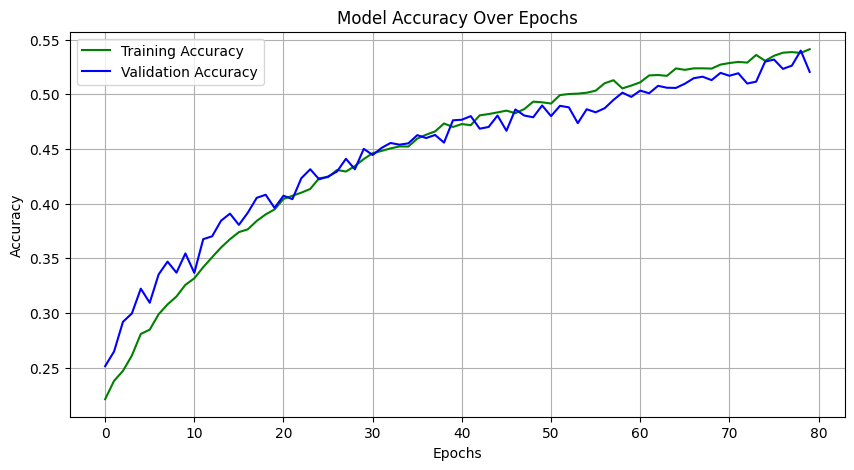

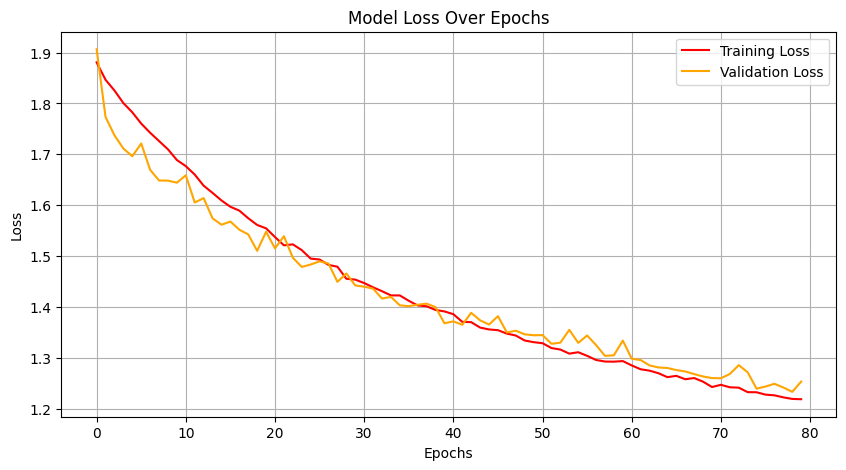

In [6]:
import matplotlib.pyplot as plt

# ===============================
# 📈 Plot Accuracy
# ===============================
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# ===============================
# 📉 Plot Loss
# ===============================
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
